Disciplina: **Mineração de Dados**

Professor: **Wilson Castello Branco Neto**

Aula 10 - Support vector machines

Nome: Wilson Castello Branco Neto

Exemplo/Atividade 1: SVM e outros classificadores com dataset Iris (tipos de flores).

#**Parte 1** - Exemplo

#Carregamento e apresentação dos dados

Leitura e apresentação do Dataset. Os quatro atributos independentes são valores contínuos que representam:
*   Sepal.Length - Comprimento da Sépala
*   Sepal.Width - Largura da Sépala
*   Petal.Length - Comprimento da Pétala
*   Petal.Width - Largura da Sépala

O último atributo representa a espécie da planta, que pode ser setosa (0), versicolor (1) ou virginica (2).

In [11]:
from sklearn import datasets

iris = datasets.load_iris()
X4 = iris.data
y4 = iris.target
print ('Formato dos dados independentes: ',X4.shape)
print ('Formato dos resultados (classe): ',y4.shape)


Formato dos dados independentes:  (150, 4)
Formato dos resultados (classe):  (150,)


Apresenta os dados dos atributos dependentes (apenas os 10 primeiros registros).

In [12]:
X4[0:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

Apresenta os dados do atributo independente (todos os registros).

In [13]:
y4

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Realiza a transformação dos atributos dependentes usando a normalização padrão (Z-Score).

In [14]:
from sklearn.preprocessing import StandardScaler

tranform = StandardScaler()
X4 = tranform.fit_transform(X4)

X4[0:10]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ],
       [-0.53717756,  1.93979142, -1.16971425, -1.05217993],
       [-1.50652052,  0.78880759, -1.34022653, -1.18381211],
       [-1.02184904,  0.78880759, -1.2833891 , -1.3154443 ],
       [-1.74885626, -0.36217625, -1.34022653, -1.3154443 ],
       [-1.14301691,  0.09821729, -1.2833891 , -1.44707648]])

#Exemplo apenas com 2 atributos

Exclui as colunas relacionadas às pétalas para criar um modelo com base apenas nos dois primeiros atributos. Esta exclusão é feita para fins didáticos, para tornar possível a visualização das classes em um gráfico com apenas duas dimensões. Em uma situação real, os atributos só devem ser excluídos caso se identifique que eles são irrelevantes para a definição do valor objetivo.

In [15]:
X2 = X4[:,:2]
y2 = y4[:]

print(X2[:10])
print(y2)

[[-0.90068117  1.01900435]
 [-1.14301691 -0.13197948]
 [-1.38535265  0.32841405]
 [-1.50652052  0.09821729]
 [-1.02184904  1.24920112]
 [-0.53717756  1.93979142]
 [-1.50652052  0.78880759]
 [-1.02184904  0.78880759]
 [-1.74885626 -0.36217625]
 [-1.14301691  0.09821729]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


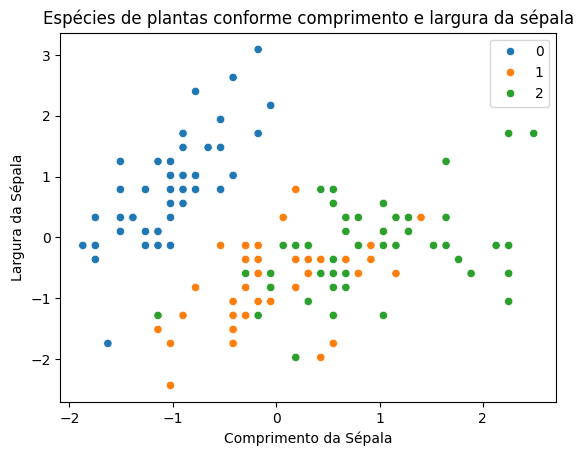

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=X2[:,0],y=X2[:,1], hue=y2, palette='tab10')
plt.title('Espécies de plantas conforme comprimento e largura da sépala')
plt.xlabel('Comprimento da Sépala')
plt.ylabel('Largura da Sépala')
plt.show()

Divide o dataset em dois conjuntos, um para treinamento e outro para teste.

In [17]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.25, random_state=42, shuffle=True)

print('Formato dos dados de treinamento')
print (X_train2.shape, y_train2.shape)

print('Formato dos dados de teste')
print (X_test2.shape, y_test2.shape)


Formato dos dados de treinamento
(112, 2) (112,)
Formato dos dados de teste
(38, 2) (38,)


Cria e treina um modelo de classificação linear rígido do tipo perceptron. Em seguida apresenta os coeficientes da reta separadora e o valor da acurácia obtida.

In [18]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

modelo = Perceptron(random_state=0)
modelo.fit(X_train2, y_train2)
y_pred2 = modelo.predict(X_test2)
acc = accuracy_score(y_test2, y_pred2)

print('Coeficientes w1 e w2 das três retas')
print (modelo.coef_)
print('Coeficiente w0 das três retas')
print (modelo.intercept_)
print('Acurácia do modelo')
print(acc)

Coeficientes w1 e w2 das três retas
[[-1.76501198  1.05276654]
 [-0.84817509 -0.92078707]
 [ 2.16486595  0.72435249]]
Coeficiente w0 das três retas
[-1.  0. -2.]
Acurácia do modelo
0.7105263157894737


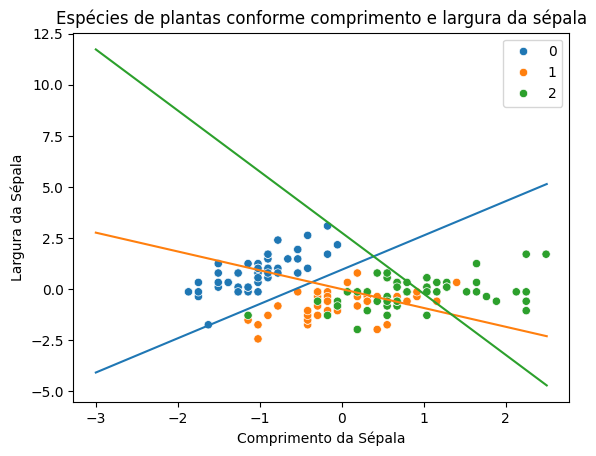

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.scatterplot(x=X2[:,0],y=X2[:,1], hue=y2, palette='tab10')
plt.title('Espécies de plantas conforme comprimento e largura da sépala')
plt.xlabel('Comprimento da Sépala')
plt.ylabel('Largura da Sépala')
xs = np.arange(-3,3,0.5)
ys = (-modelo.intercept_[0]-xs*modelo.coef_[0,0])/modelo.coef_[0,1]
plt.plot(xs,ys)
ys = (-modelo.intercept_[1]-xs*modelo.coef_[1,0])/modelo.coef_[1,1]
plt.plot(xs,ys)
ys = (-modelo.intercept_[2]-xs*modelo.coef_[2,0])/modelo.coef_[2,1]
plt.plot(xs,ys)
plt.show()

Cria e treina um modelo de classificação linear esticástico. Em seguida apresenta os coeficientes da reta separadora e o valor da acurácia obtida.

In [23]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

modelo = SGDClassifier(random_state=0)
modelo.fit(X_train2, y_train2)
y_pred2 = modelo.predict(X_test2)
acc = accuracy_score(y_test2, y_pred2)

print('Coeficientes w1 e w2 das três retas')
print (modelo.coef_)
print('Coeficiente w0 das três retas')
print (modelo.intercept_).
print('Acurácia do modelo')
print(acc)

Coeficientes w1 e w2 das três retas
[[-31.77859188  15.45173017]
 [  5.89966898  -4.53527527]
 [  5.18414646  -2.66894801]]
Coeficiente w0 das três retas
[-25.63826661   1.15435441  -1.42578621]
Acurácia do modelo
0.6842105263157895


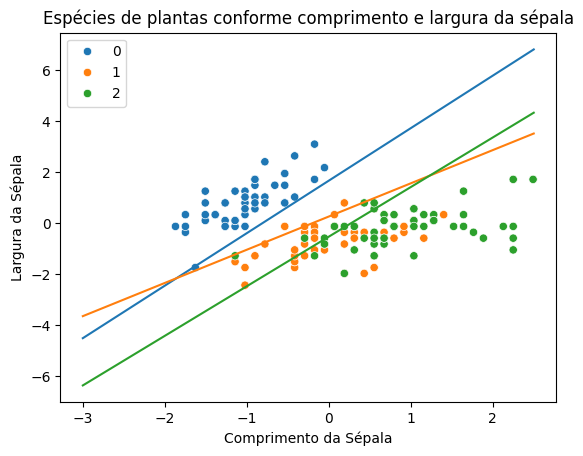

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.scatterplot(x=X2[:,0],y=X2[:,1], hue=y2, palette='tab10')
plt.title('Espécies de plantas conforme comprimento e largura da sépala')
plt.xlabel('Comprimento da Sépala')
plt.ylabel('Largura da Sépala')
xs = np.arange(-3,3,0.5)
ys = (-modelo.intercept_[0]-xs*modelo.coef_[0,0])/modelo.coef_[0,1]
plt.plot(xs,ys)
ys = (-modelo.intercept_[1]-xs*modelo.coef_[1,0])/modelo.coef_[1,1]
plt.plot(xs,ys)
ys = (-modelo.intercept_[2]-xs*modelo.coef_[2,0])/modelo.coef_[2,1]
plt.plot(xs,ys)
plt.show()

Cria um SVM usando uma função de Kernel linear. Em seguida apresenta os coeficientes da reta separadora e o valor da acurácia obtida.

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

modelo = SVC(kernel='linear')
modelo.fit(X_train2, y_train2)
y_pred2 = modelo.predict(X_test2)
acc = accuracy_score(y_test2, y_pred2)

print('Coeficientes w1 e w2 das três retas')
print (modelo.coef_)
print('Coeficiente w0 das três retas')
print (modelo.intercept_)
print('Acurácia do modelo')
print(acc)

Coeficientes w1 e w2 das três retas
[[-2.06317741  1.08601944]
 [-1.85253172  0.78008843]
 [-1.08188936 -0.4274481 ]]
Coeficiente w0 das três retas
[-1.46496523 -0.79005204  0.36199527]
Acurácia do modelo
0.8421052631578947


Apresenta as retas separadoras do classificador linear do SVM

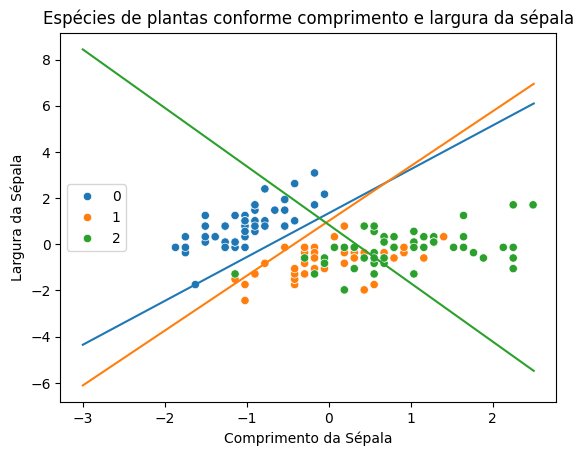

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.scatterplot(x=X2[:,0],y=X2[:,1], hue=y2, palette='tab10')
plt.title('Espécies de plantas conforme comprimento e largura da sépala')
plt.xlabel('Comprimento da Sépala')
plt.ylabel('Largura da Sépala')
xs = np.arange(-3,3,0.5)
ys = (-modelo.intercept_[0]-xs*modelo.coef_[0,0])/modelo.coef_[0,1]
plt.plot(xs,ys)
ys = (-modelo.intercept_[1]-xs*modelo.coef_[1,0])/modelo.coef_[1,1]
plt.plot(xs,ys)
ys = (-modelo.intercept_[2]-xs*modelo.coef_[2,0])/modelo.coef_[2,1]
plt.plot(xs,ys)
plt.show()

#Exemplo com 4 atributos

Retorna aos dados originais, com os 4 atributos. Considerando o exemplo anterior, aqui já há um aumento nas dimensões do problema ao incluir os valores relacionados ao comprimento e a largura da pétala.

In [30]:
from sklearn.model_selection import train_test_split

X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y4, test_size=0.25, random_state=42, shuffle=True)

print('Formato dos dados de treinamento')
print (X_train4.shape, y_train4.shape)

print('Formato dos dados de teste')
print (X_test4.shape, y_test4.shape)


Formato dos dados de treinamento
(112, 4) (112,)
Formato dos dados de teste
(38, 4) (38,)


Cria e treina um modelo de classificação linear rígido. Em seguida apresenta os coeficientes da reta separadora e o valor da acurácia obtida.

In [31]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

modelo = Perceptron(random_state=0)
modelo.fit(X_train4, y_train4)
y_pred4 = modelo.predict(X_test4)
acc = accuracy_score(y_test4, y_pred4)

print('Coeficientes w1 e w2 das três retas')
print (modelo.coef_)
print('Coeficiente w0 das três retas')
print (modelo.intercept_)
print('Acurácia do modelo')
print(acc)

Coeficientes w1 e w2 das três retas
[[-0.55333328  0.36217625 -1.0469454  -0.79067065]
 [-0.13732359 -2.0380087   2.22575364 -3.02929533]
 [-1.32880765 -1.83850484  6.14185235  5.12751235]]
Coeficiente w0 das três retas
[-1. -2. -7.]
Acurácia do modelo
0.8947368421052632


Cria e treina um modelo de classificação linear estocástica. Em seguida apresenta os coeficientes da reta separadora e o valor da acurácia obtida.

In [32]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

modelo = SGDClassifier(random_state=0)
modelo.fit(X_train4, y_train4)
y_pred4 = modelo.predict(X_test4)
acc = accuracy_score(y_test4, y_pred4)

print('Coeficientes w1 e w2 das três retas')
print (modelo.coef_)
print('Coeficiente w0 das três retas')
print (modelo.intercept_)
print('Acurácia do modelo')
print(acc)

Coeficientes w1 e w2 das três retas
[[ -3.10338348   2.03127451  -5.87181943  -4.43449609]
 [ -5.61794268  -8.15390574   4.96437357  -9.42842305]
 [  3.47904043 -10.85954489  32.06690767  24.78212596]]
Coeficiente w0 das três retas
[-10.         -11.09024804 -35.93889543]
Acurácia do modelo
0.8421052631578947


Cria e treina um SVM linear, com valor de 1 para o parâmetro C. Em seguida apresenta os coeficientes da reta separadora e o valor da acurácia obtida.

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

modelo = SVC(kernel='linear', C=1)
modelo.fit(X_train4, y_train4)
y_pred4 = modelo.predict(X_test4)
acc = accuracy_score(y_test4, y_pred4)

print('Coeficientes w1 e w2 das três retas')
print (modelo.coef_)
print('Coeficiente w0 das três retas')
print (modelo.intercept_)
print('Acurácia do modelo')
print(acc)


Coeficientes w1 e w2 das três retas
[[-0.43857952  0.33213012 -0.89186902 -0.92278364]
 [-0.06473327  0.13858127 -0.553431   -0.55666399]
 [ 0.18306704  0.75376045 -2.40939766 -2.10017224]]
Coeficiente w0 das três retas
[-1.47333522 -0.2957917   3.0002107 ]
Acurácia do modelo
0.9736842105263158


#**Parte 2** - Atividade

Consulte a documentação do SVM disponível no link abaixo, para realizar as atividades a seguir.

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

Crie diferentes classificadores SVM, alterando o tipo da função de Kernel utilizada (mantenha o parâmetro C = 1).

Analise os resultados para identificar qual função de Kernel levou ao melhor resultado. Além de apresentar a acurácia de cada modelo, apresente o tempo de processamento necessário para seu o treinamento e para a realização das predições.


LINEAR

In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

for c in range(1,101):

 start_time = time.time()
 modelo = SVC(kernel='linear', C=1)
 modelo.fit(X_train4, y_train4)
 y_pred4 = modelo.predict(X_test4)
 acc = accuracy_score(y_test4, y_pred4)
 end_time = time.time()
 tempo_total = end_time - start_time


 print('Tempo:', tempo_total)
 print('Acurácia do modelo')
 print(acc)
 print(c)

Tempo: 0.006234407424926758
Acurácia do modelo
0.9736842105263158


POLY

In [57]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

for c in range(1,101):

 start_time = time.time()
 modelo = SVC(kernel='poly', C=1)
 modelo.fit(X_train4, y_train4)
 y_pred4 = modelo.predict(X_test4)
 acc = accuracy_score(y_test4, y_pred4)
 end_time = time.time()
 tempo_total = end_time - start_time


 print('Tempo:', tempo_total)
 print('Acurácia do modelo')
 print(acc)
 print(c)

Tempo: 0.0069315433502197266
Acurácia do modelo
0.9736842105263158
1
Tempo: 0.0042765140533447266
Acurácia do modelo
0.9736842105263158
2
Tempo: 0.0031931400299072266
Acurácia do modelo
0.9736842105263158
3
Tempo: 0.0031120777130126953
Acurácia do modelo
0.9736842105263158
4
Tempo: 0.003032684326171875
Acurácia do modelo
0.9736842105263158
5
Tempo: 0.003074169158935547
Acurácia do modelo
0.9736842105263158
6
Tempo: 0.003224611282348633
Acurácia do modelo
0.9736842105263158
7
Tempo: 0.003123044967651367
Acurácia do modelo
0.9736842105263158
8
Tempo: 0.0031266212463378906
Acurácia do modelo
0.9736842105263158
9
Tempo: 0.0032203197479248047
Acurácia do modelo
0.9736842105263158
10
Tempo: 0.0030672550201416016
Acurácia do modelo
0.9736842105263158
11
Tempo: 0.003107309341430664
Acurácia do modelo
0.9736842105263158
12
Tempo: 0.003232240676879883
Acurácia do modelo
0.9736842105263158
13
Tempo: 0.00307464599609375
Acurácia do modelo
0.9736842105263158
14
Tempo: 0.003107309341430664
Acurácia 

RBF

In [58]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

for c in range(1,101):

 start_time = time.time()
 modelo = SVC(kernel='rbf', C=1)
 modelo.fit(X_train4, y_train4)
 y_pred4 = modelo.predict(X_test4)
 acc = accuracy_score(y_test4, y_pred4)
 end_time = time.time()
 tempo_total = end_time - start_time


 print('Tempo:', tempo_total)
 print('Acurácia do modelo')
 print(acc)
 print(c)

Tempo: 0.007906198501586914
Acurácia do modelo
1.0
1
Tempo: 0.007956743240356445
Acurácia do modelo
1.0
2
Tempo: 0.0076067447662353516
Acurácia do modelo
1.0
3
Tempo: 0.0054433345794677734
Acurácia do modelo
1.0
4
Tempo: 0.007582187652587891
Acurácia do modelo
1.0
5
Tempo: 0.007509708404541016
Acurácia do modelo
1.0
6
Tempo: 0.0033426284790039062
Acurácia do modelo
1.0
7
Tempo: 0.003206014633178711
Acurácia do modelo
1.0
8
Tempo: 0.003195047378540039
Acurácia do modelo
1.0
9
Tempo: 0.0032951831817626953
Acurácia do modelo
1.0
10
Tempo: 0.0031282901763916016
Acurácia do modelo
1.0
11
Tempo: 0.0031518936157226562
Acurácia do modelo
1.0
12
Tempo: 0.0038690567016601562
Acurácia do modelo
1.0
13
Tempo: 0.0034520626068115234
Acurácia do modelo
1.0
14
Tempo: 0.0033354759216308594
Acurácia do modelo
1.0
15
Tempo: 0.003269672393798828
Acurácia do modelo
1.0
16
Tempo: 0.0033147335052490234
Acurácia do modelo
1.0
17
Tempo: 0.003258943557739258
Acurácia do modelo
1.0
18
Tempo: 0.003234624862670898

SIGMOID

In [59]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

for c in range(1,101):

 start_time = time.time()
 modelo = SVC(kernel='sigmoid', C=1)
 modelo.fit(X_train4, y_train4)
 y_pred4 = modelo.predict(X_test4)
 acc = accuracy_score(y_test4, y_pred4)
 end_time = time.time()
 tempo_total = end_time - start_time


 print('Tempo:', tempo_total)
 print('Acurácia do modelo')
 print(acc)
 print(c)

Tempo: 0.005040407180786133
Acurácia do modelo
0.868421052631579
1
Tempo: 0.004178524017333984
Acurácia do modelo
0.868421052631579
2
Tempo: 0.003774881362915039
Acurácia do modelo
0.868421052631579
3
Tempo: 0.0036211013793945312
Acurácia do modelo
0.868421052631579
4
Tempo: 0.0036144256591796875
Acurácia do modelo
0.868421052631579
5
Tempo: 0.0036911964416503906
Acurácia do modelo
0.868421052631579
6
Tempo: 0.003760099411010742
Acurácia do modelo
0.868421052631579
7
Tempo: 0.0034558773040771484
Acurácia do modelo
0.868421052631579
8
Tempo: 0.003459930419921875
Acurácia do modelo
0.868421052631579
9
Tempo: 0.0035104751586914062
Acurácia do modelo
0.868421052631579
10
Tempo: 0.0068018436431884766
Acurácia do modelo
0.868421052631579
11
Tempo: 0.003875732421875
Acurácia do modelo
0.868421052631579
12
Tempo: 0.003398418426513672
Acurácia do modelo
0.868421052631579
13
Tempo: 0.003691434860229492
Acurácia do modelo
0.868421052631579
14
Tempo: 0.0035152435302734375
Acurácia do modelo
0.8684

Para cada tipo de função de Kernel, incremente o valor de C de 1 em 1, até C = 100, e analise os resultados de acurácia e tempo de processamento. Até que valor de C houve incremento na acurácia. O que aconteceu com o tempo de treinamento?

In [56]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

for c in range(1,101):

 start_time = time.time()
 modelo = SVC(kernel='linear', C=1)
 modelo.fit(X_train4, y_train4)
 y_pred4 = modelo.predict(X_test4)
 acc = accuracy_score(y_test4, y_pred4)
 end_time = time.time()
 tempo_total = end_time - start_time


 print('Tempo:', tempo_total)
 print('Acurácia do modelo')
 print(acc)
 print(c)

Tempo: 0.005152463912963867
Acurácia do modelo
0.9736842105263158
1
Tempo: 0.0033457279205322266
Acurácia do modelo
0.9736842105263158
2
Tempo: 0.00279998779296875
Acurácia do modelo
0.9736842105263158
3
Tempo: 0.002821207046508789
Acurácia do modelo
0.9736842105263158
4
Tempo: 0.0029897689819335938
Acurácia do modelo
0.9736842105263158
5
Tempo: 0.003047943115234375
Acurácia do modelo
0.9736842105263158
6
Tempo: 0.0029914379119873047
Acurácia do modelo
0.9736842105263158
7
Tempo: 0.002724170684814453
Acurácia do modelo
0.9736842105263158
8
Tempo: 0.002945423126220703
Acurácia do modelo
0.9736842105263158
9
Tempo: 0.002920389175415039
Acurácia do modelo
0.9736842105263158
10
Tempo: 0.0029265880584716797
Acurácia do modelo
0.9736842105263158
11
Tempo: 0.003131866455078125
Acurácia do modelo
0.9736842105263158
12
Tempo: 0.003312349319458008
Acurácia do modelo
0.9736842105263158
13
Tempo: 0.0027816295623779297
Acurácia do modelo
0.9736842105263158
14
Tempo: 0.0028734207153320312
Acurácia d